<a href="https://colab.research.google.com/github/aot-abhishekyadav/Machine-Learning-Fundamentals/blob/main/17-RandomSample/random-sample-imputation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Random Sample Imputation ek missing value imputation technique hai jo missing values ko usi column ke randomly selected existing values se fill karti hai.

Distribution and variance jo hai usme jadda differnce nhi aata hai but correlation mai difference aa jaat hai

## ✅ Advantages

### 1. Distribution preserve karta hai
Randomly existing values choose karne ki wajah se original data distribution ko relatively maintain karta hai.

### 2. Mean/Median ki problem kam hoti hai
Mean ya median se har missing value fill karne par data mein artificial concentration aa sakti hai. Random sampling mein ye problem kam hoti hai.

### 3. Easy to understand and implement
Python/Pandas mein easily implement kar sakte hain.

### 4. Variance preserve kar sakta hai
Mean imputation ke comparison mein data ki variability ko better preserve karta hai.

### 5. Numerical aur categorical dono data par use ho sakta hai
Example: Age ke liye random age aur City ke liye random existing city.

## ❌ Disadvantages

### 1. Randomness ki wajah se result change ho sakta hai
Har execution mein different random values select ho sakti hain.
### 2. Reproducibility issue
Agar random_state set nahi kiya, to same dataset par different results mil sakte hain.
### 3. Relationship between features preserve nahi karta
Example: Age aur Salary related hain, lekin random Age select karne se actual relationship disturb ho sakta hai.
### 4. Outliers ka risk
Agar column mein outliers hain, random sampling se missing value mein bhi outlier aa sakta hai.
### 5. Large missing percentage mein suitable nahi
Agar bahut saari values missing hain, to available values se random sampling reliable nahi ho sakti.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Titanic1.csv', usecols=['Age', 'Fare', 'Survived'])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
df.isnull().mean()*100

,0
Survived,0.00000
Age,19.86532
Fare,0.00000


In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [ ]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [ ]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [ ]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]  # iska mean age_imputed mai jo vale null hai usko extract kar do

,Age_imputed
77,NaN
868,NaN
334,NaN
295,NaN
792,NaN
...,...
674,NaN
466,NaN
584,NaN
527,NaN


In [ ]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([32.  , 48.  , 19.  , 33.  , 28.  , 16.  , 29.  , 28.  , 17.  ,
        8.  , 25.  , 56.  , 45.  , 18.  , 36.  , 21.  , 40.  , 52.  ,
       20.  , 36.  , 26.  , 36.  , 23.  , 21.  , 60.  , 30.  , 25.  ,
       36.  , 54.  , 62.  ,  1.  , 48.  , 38.  , 21.  , 30.  , 45.  ,
       16.  , 47.  , 20.  , 23.  ,  0.42, 21.  , 31.  , 24.  , 32.  ,
       14.  , 28.  , 39.  , 45.5 , 43.  , 33.  , 21.  , 28.  , 39.  ,
       33.  , 20.  , 41.  , 18.  ,  9.  , 17.  , 39.  , 27.  , 36.  ,
       27.  , 53.  , 51.  , 35.  , 25.  , 39.  , 31.  , 36.  ,  2.  ,
       40.  , 21.  , 11.  , 47.  , 40.  , 23.  , 38.  , 58.  , 29.  ,
       31.  , 34.  , 41.  , 26.  ,  4.  , 40.  , 35.  , 24.  , 28.  ,
       17.  , 24.  ,  4.  , 45.  , 28.5 , 31.  , 25.  , 42.  , 16.  ,
       35.  , 18.  , 28.  , 22.  , 15.  , 52.  , 30.  , 21.  ,  4.  ,
        0.75, 15.  , 34.  , 14.  , 65.  ,  9.  , 58.  , 60.  , 30.  ,
       27.  , 29.  , 41.  , 50.  , 62.  ,  5.  , 33.  , 23.  , 32.  ,
       36.  , 30.  ,

In [ ]:
X_train['Age'].isnull().sum()

np.int64(148)

In [ ]:
X_test['Age'].isnull().sum()

np.int64(29)

Random Imputation

In [ ]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

/tmp/ipykernel_977/3090101260.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
/tmp/ipykernel_977/3090101260.py

In [ ]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,31.0
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [ ]:
X_train.sample(5)

,Age,Fare,Age_imputed
847,35.0,7.8958,35.0
359,NaN,7.8792,42.0
867,31.0,50.4958,31.0
670,40.0,39.0000,40.0
745,70.0,71.0000,70.0


Distribution

/tmp/ipykernel_977/2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
/tmp/ipykernel_977/2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)


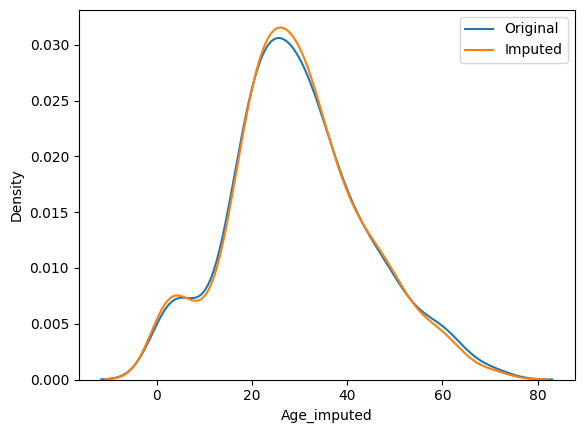

In [ ]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()  # no diff between after imputaion or before imputation in age

Variance

In [ ]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  197.8959698343845


In [ ]:
print('Original variable variance: ', X_test['Age'].var())
print('Variance after random imputation: ', X_test['Age_imputed'].var())

Original variable variance:  237.50093573154342
Variance after random imputation:  222.23064608624705


Covariance

In [ ]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,73.595294
Age,71.512440,204.349513,204.349513
Age_imputed,73.595294,204.349513,197.895970


In [ ]:
X_train[['Fare', 'Age', 'Age_imputed']].corr()

,Fare,Age,Age_imputed
Fare,1.000000,0.095814,0.107502
Age,0.095814,1.000000,1.000000
Age_imputed,0.107502,1.000000,1.000000


<Axes: >

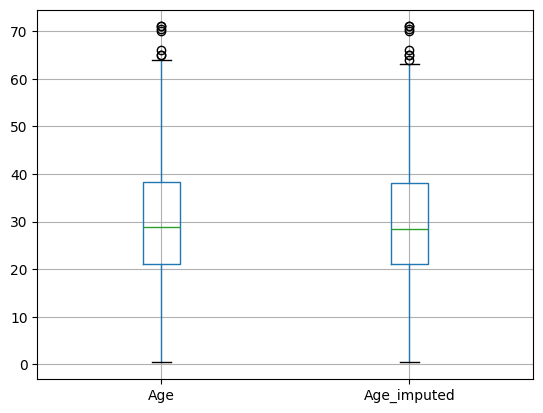

In [ ]:
X_train[[ 'Age', 'Age_imputed']].boxplot()

agr hum server pai random imputaion use kar kai deploy kar rhe hai to same fare kai liye har baar random value naa dai uske liye hum yai code use karte hai e.g agr 50 fair ki value missing hai usko random imputation ki vjh sai 40 value mil gyi hai to vo har baar 50 kai liye same value dai change naa kare

In [ ]:
# sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

## Working With Categorical Data

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/house-train.csv')

In [ ]:
df2

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
data = df2[['GarageQual','FireplaceQu', 'SalePrice']]

In [ ]:
data.head()

,GarageQual,FireplaceQu,SalePrice
0,TA,NaN,208500
1,TA,TA,181500
2,TA,TA,223500
3,TA,Gd,140000
4,TA,TA,250000


In [ ]:
data.isnull().sum()

,0
GarageQual,81
FireplaceQu,690
SalePrice,0


In [ ]:
data.isnull().mean() * 100

,0
GarageQual,5.547945
FireplaceQu,47.260274
SalePrice,0.000000


In [ ]:
X = data
y = data['SalePrice']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [ ]:
X_train.sample(5)

,GarageQual,FireplaceQu,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1395,TA,Gd,281213,TA,Gd
544,TA,Gd,179665,TA,Gd
1250,TA,TA,244000,TA,TA
66,TA,Gd,180000,TA,Gd
150,TA,NaN,122000,TA,NaN


In [ ]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_977/856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/tmp/

In [ ]:
X_train.sample(5)

,GarageQual,FireplaceQu,SalePrice,GarageQual_imputed,FireplaceQu_imputed
817,TA,Gd,271000,TA,Gd
1088,TA,NaN,137500,TA,TA
178,TA,Gd,501837,TA,Gd
3,TA,Gd,140000,TA,Gd
954,NaN,NaN,127500,TA,Gd


In [ ]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [ ]:
temp

,original,imputed
TA,0.951043,0.948630
Fa,0.037171,0.039384
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [ ]:
temp1 = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp1.columns = ['original', 'imputed']


In [ ]:
temp1

,original,imputed
Gd,0.494272,0.644220
TA,0.412439,0.545455
Fa,0.040917,0.052750
Po,0.027823,0.035915
Ex,0.024550,0.032548


/tmp/ipykernel_977/1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipykernel_977/1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu']

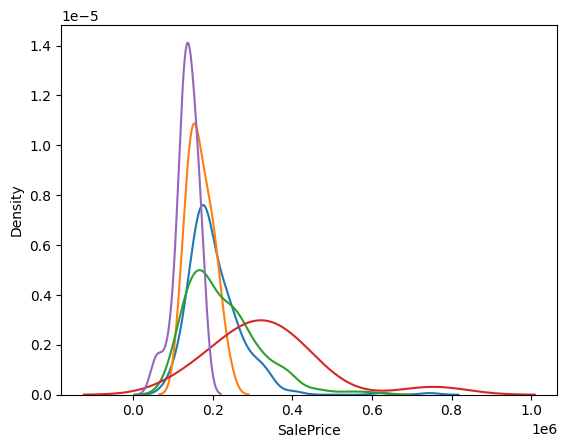

In [ ]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

/tmp/ipykernel_977/722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipykernel_977/722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['Firepla

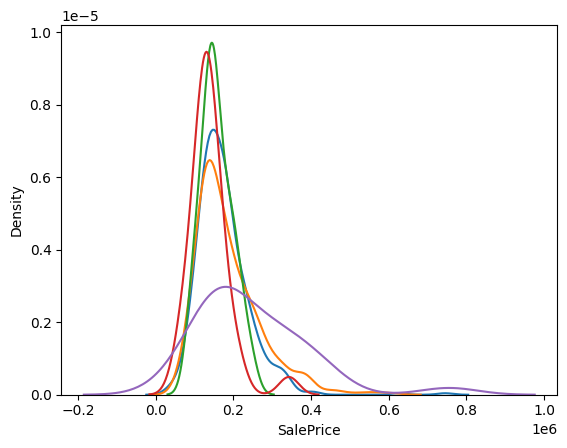

In [ ]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()

/tmp/ipykernel_977/4285534628.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['GarageQual'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipykernel_977/4285534628.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['GarageQual'] =

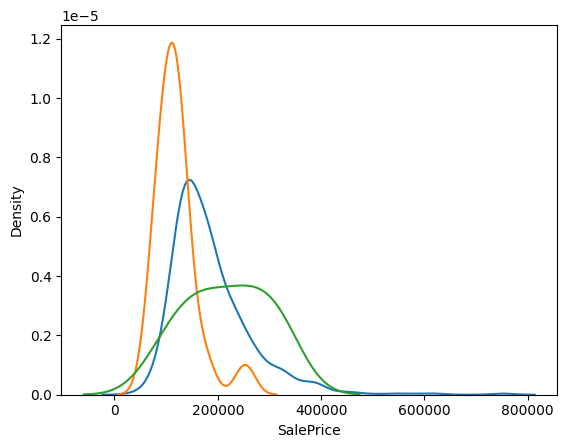

In [ ]:
for category in X_train['GarageQual'].dropna().unique():
    sns.distplot(X_train[X_train['GarageQual'] == category]['SalePrice'],hist=False,label=category)
plt.show()

/tmp/ipykernel_977/643172105.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['GarageQual_imputed'] == category]['SalePrice'],hist=False,label=category)
/tmp/ipykernel_977/643172105.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['GarageQu

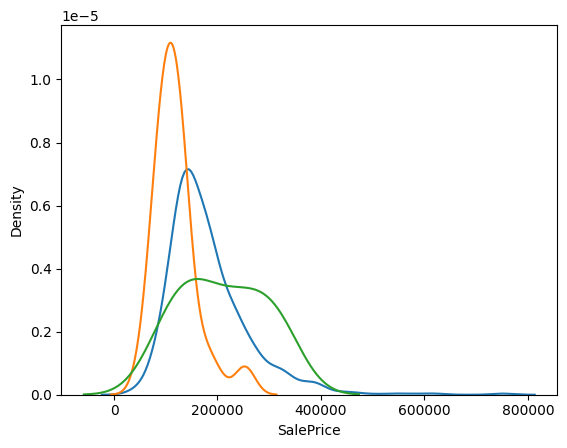

In [ ]:
for category in X_train['GarageQual_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['GarageQual_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()